In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('SriLanka_Weather_Dataset.csv')
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 147,480 rows × 24 columns


,time,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,sunset,...,precipitation_hours,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant,et0_fao_evapotranspiration,latitude,longitude,elevation,country,city
0,2010-01-01,2,30.0,22.7,26.1,34.4,25.2,29.2,2010-01-01T00:52,2010-01-01T12:35,...,0.0,11.7,27.4,20,4.58,7.0,79.899994,16.0,Sri Lanka,Colombo
1,2010-01-02,51,29.9,23.5,26.2,33.8,26.2,29.8,2010-01-02T00:52,2010-01-02T12:36,...,1.0,13.0,27.0,24,3.84,7.0,79.899994,16.0,Sri Lanka,Colombo
2,2010-01-03,51,29.5,23.2,26.0,34.3,26.3,29.9,2010-01-03T00:53,2010-01-03T12:36,...,3.0,12.3,27.4,16,3.65,7.0,79.899994,16.0,Sri Lanka,Colombo
3,2010-01-04,2,28.9,21.9,25.3,31.6,23.4,27.8,2010-01-04T00:53,2010-01-04T12:37,...,0.0,17.0,34.6,356,3.79,7.0,79.899994,16.0,Sri Lanka,Colombo
4,2010-01-05,1,28.1,21.3,24.5,30.1,23.1,26.1,2010-01-05T00:53,2010-01-05T12:37,...,0.0,18.7,37.1,355,4.97,7.0,79.899994,16.0,Sri Lanka,Colombo


In [2]:
print("=== Data Types ===")
print(df.dtypes)
print(f"\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print(f"\n=== Basic Statistics ===")
df.describe().round(2)

=== Data Types ===
time                           object
weathercode                     int64
temperature_2m_max            float64
temperature_2m_min            float64
temperature_2m_mean           float64
apparent_temperature_max      float64
apparent_temperature_min      float64
apparent_temperature_mean     float64
sunrise                        object
sunset                         object
shortwave_radiation_sum       float64
precipitation_sum             float64
rain_sum                      float64
snowfall_sum                  float64
precipitation_hours           float64
windspeed_10m_max             float64
windgusts_10m_max             float64
winddirection_10m_dominant      int64
et0_fao_evapotranspiration    float64
latitude                      float64
longitude                     float64
elevation                     float64
country                        object
city                           object
dtype: object

=== Missing Values ===
No missing values found.

=== B

,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,shortwave_radiation_sum,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant,et0_fao_evapotranspiration,latitude,longitude,elevation
count,147480.00,147480.00,147480.00,147480.00,147480.00,147480.00,147480.00,147480.00,147480.00,147480.00,147480.0,147480.00,147480.00,147480.00,147480.00,147480.00,147480.00,147480.00,147480.00
mean,46.65,29.24,23.90,26.23,34.11,27.71,30.32,18.48,5.98,5.98,0.0,8.76,15.56,34.80,182.88,3.90,7.12,80.26,111.73
std,21.62,2.12,2.06,1.84,2.97,2.84,2.54,4.21,10.22,10.22,0.0,7.19,6.21,10.21,93.67,1.02,0.80,0.49,266.38
min,0.00,17.50,12.10,16.30,18.50,10.50,16.30,1.23,0.00,0.00,0.0,0.00,2.20,11.50,0.00,0.42,6.00,79.80,0.00
25%,51.00,28.20,23.10,25.60,32.40,26.40,29.20,16.22,0.40,0.40,0.0,2.00,11.00,26.60,88.00,3.26,6.80,79.90,7.00
50%,53.00,29.20,24.30,26.40,34.20,28.40,30.80,19.13,2.60,2.60,0.0,8.00,15.00,33.10,215.00,3.89,6.90,80.00,14.00
75%,61.00,30.40,25.20,27.20,36.10,29.60,31.90,21.51,7.50,7.50,0.0,14.00,18.90,41.80,249.00,4.55,7.40,80.40,27.00
max,65.00,37.50,30.00,31.80,43.40,34.70,37.40,28.98,338.80,338.80,0.0,24.00,50.20,91.80,360.00,8.14,9.70,81.80,1281.00


In [3]:
print(f"Unique cities: {df['city'].nunique()}")
print(f"Cities: {sorted(df['city'].unique())}")
print(f"\nDate range: {df['time'].min()} to {df['time'].max()}")
print(f"\nTarget variable (precipitation_sum) statistics:")
print(df['precipitation_sum'].describe().round(2))
print(f"\nZero-precipitation days: {(df['precipitation_sum'] == 0).sum():,} ({(df['precipitation_sum'] == 0).mean()*100:.1f}%)")
print(f"Snowfall_sum unique values: {df['snowfall_sum'].unique()} (always zero — expected for tropical Sri Lanka)")

Unique cities: 30
Cities: ['Athurugiriya', 'Badulla', 'Bentota', 'Colombo', 'Galle', 'Gampaha', 'Hambantota', 'Hatton', 'Jaffna', 'Kalmunai', 'Kalutara', 'Kandy', 'Kesbewa', 'Kolonnawa', 'Kurunegala', 'Mabole', 'Maharagama', 'Mannar', 'Matale', 'Matara', 'Moratuwa', 'Mount Lavinia', 'Negombo', 'Oruwala', 'Pothuhera', 'Puttalam', 'Ratnapura', 'Sri Jayewardenepura Kotte', 'Trincomalee', 'Weligama']

Date range: 2010-01-01 to 2023-06-17

Target variable (precipitation_sum) statistics:
count    147480.00
mean          5.98
std          10.22
min           0.00
25%           0.40
50%           2.60
75%           7.50
max         338.80
Name: precipitation_sum, dtype: float64

Zero-precipitation days: 26,727 (18.1%)
Snowfall_sum unique values: [0.] (always zero — expected for tropical Sri Lanka)


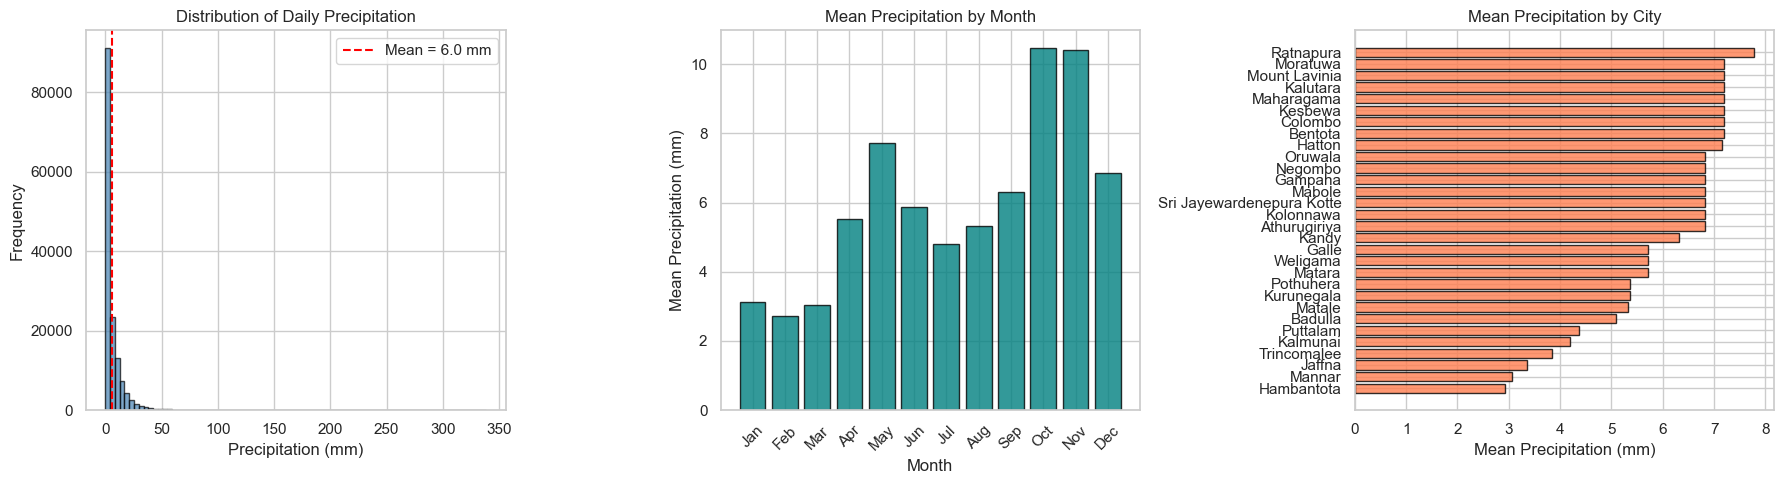

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['precipitation_sum'], bins=80, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distribution of Daily Precipitation')
axes[0].set_xlabel('Precipitation (mm)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['precipitation_sum'].mean(), color='red', linestyle='--', label=f"Mean = {df['precipitation_sum'].mean():.1f} mm")
axes[0].legend()

df['time_dt'] = pd.to_datetime(df['time'])
monthly_avg = df.groupby(df['time_dt'].dt.month)['precipitation_sum'].mean()
axes[1].bar(monthly_avg.index, monthly_avg.values, color='teal', edgecolor='black', alpha=0.8)
axes[1].set_title('Mean Precipitation by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Mean Precipitation (mm)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

city_avg = df.groupby('city')['precipitation_sum'].mean().sort_values(ascending=True)
axes[2].barh(city_avg.index, city_avg.values, color='coral', edgecolor='black', alpha=0.8)
axes[2].set_title('Mean Precipitation by City')
axes[2].set_xlabel('Mean Precipitation (mm)')

plt.tight_layout()
plt.show()

In [5]:
df['time_dt'] = pd.to_datetime(df['time'])
df['month'] = df['time_dt'].dt.month
df['day_of_year'] = df['time_dt'].dt.dayofyear
df['year'] = df['time_dt'].dt.year

df['sunrise_dt'] = pd.to_datetime(df['sunrise'])
df['sunset_dt'] = pd.to_datetime(df['sunset'])
df['day_length_hours'] = (df['sunset_dt'] - df['sunrise_dt']).dt.total_seconds() / 3600

wind_dir_rad = np.deg2rad(df['winddirection_10m_dominant'])
df['wind_dir_sin'] = np.sin(wind_dir_rad)
df['wind_dir_cos'] = np.cos(wind_dir_rad)

from sklearn.preprocessing import LabelEncoder
le_city = LabelEncoder()
df['city_encoded'] = le_city.fit_transform(df['city'])

print("Engineered features created:")
print(f"  - month: {df['month'].min()} to {df['month'].max()}")
print(f"  - day_of_year: {df['day_of_year'].min()} to {df['day_of_year'].max()}")
print(f"  - year: {df['year'].min()} to {df['year'].max()}")
print(f"  - day_length_hours: {df['day_length_hours'].min():.2f} to {df['day_length_hours'].max():.2f}")
print(f"  - wind_dir_sin: {df['wind_dir_sin'].min():.3f} to {df['wind_dir_sin'].max():.3f}")
print(f"  - wind_dir_cos: {df['wind_dir_cos'].min():.3f} to {df['wind_dir_cos'].max():.3f}")
print(f"  - city_encoded: {df['city_encoded'].nunique()} unique cities")

Engineered features created:
  - month: 1 to 12
  - day_of_year: 1 to 366
  - year: 2010 to 2023
  - day_length_hours: 11.55 to 12.70
  - wind_dir_sin: -1.000 to 1.000
  - wind_dir_cos: -1.000 to 1.000
  - city_encoded: 30 unique cities


In [6]:
drop_cols = [
    'time', 'time_dt', 'sunrise', 'sunset', 'sunrise_dt', 'sunset_dt',
    'rain_sum', 'snowfall_sum', 'precipitation_hours', 'weathercode',
    'country', 'city', 'winddirection_10m_dominant'
]

target = 'precipitation_sum'

feature_cols = [c for c in df.columns if c not in drop_cols + [target]]

X = df[feature_cols].copy()
y = df[target].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

Feature matrix shape: (147480, 20)
Target vector shape: (147480,)

Features (20):
   1. temperature_2m_max
   2. temperature_2m_min
   3. temperature_2m_mean
   4. apparent_temperature_max
   5. apparent_temperature_min
   6. apparent_temperature_mean
   7. shortwave_radiation_sum
   8. windspeed_10m_max
   9. windgusts_10m_max
  10. et0_fao_evapotranspiration
  11. latitude
  12. longitude
  13. elevation
  14. month
  15. day_of_year
  16. year
  17. day_length_hours
  18. wind_dir_sin
  19. wind_dir_cos
  20. city_encoded


In [7]:
print("Missing values in feature matrix:")
missing_features = X.isnull().sum()
print(missing_features[missing_features > 0] if missing_features.sum() > 0 else "  None — no imputation needed.")

print(f"\nMissing values in target: {y.isnull().sum()}")

if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    before = len(X)
    mask = X.notnull().all(axis=1) & y.notnull()
    X = X[mask]
    y = y[mask]
    print(f"  Dropped {before - len(X)} rows with missing values.")

Missing values in feature matrix:
  None — no imputation needed.

Missing values in target: 0


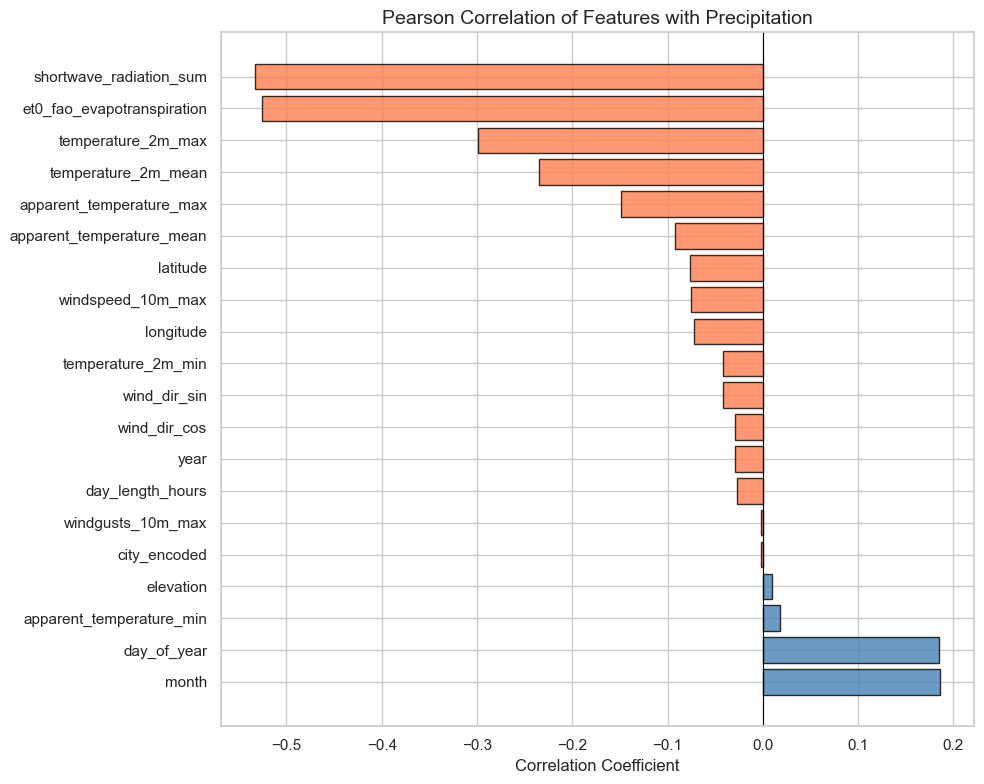

In [8]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = X[numeric_features].corrwith(y).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
corr_data = corr_matrix.reset_index()
corr_data.columns = ['Feature', 'Correlation with Precipitation']
colors = ['steelblue' if v >= 0 else 'coral' for v in corr_data['Correlation with Precipitation']]
ax.barh(corr_data['Feature'], corr_data['Correlation with Precipitation'], color=colors, edgecolor='black', alpha=0.8)
ax.set_title('Pearson Correlation of Features with Precipitation', fontsize=14)
ax.set_xlabel('Correlation Coefficient')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

sorted_indices = df['time_dt'].argsort().values  # temporal ordering
X_sorted = X.iloc[sorted_indices].reset_index(drop=True)
y_sorted = y.iloc[sorted_indices].reset_index(drop=True)

n = len(X_sorted)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

X_train = X_sorted.iloc[:train_end]
y_train = y_sorted.iloc[:train_end]

X_val = X_sorted.iloc[train_end:val_end]
y_val = y_sorted.iloc[train_end:val_end]

X_test = X_sorted.iloc[val_end:]
y_test = y_sorted.iloc[val_end:]

print(f"Training set:   {X_train.shape[0]:>7,} samples ({X_train.shape[0]/n*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:>7,} samples ({X_val.shape[0]/n*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:>7,} samples ({X_test.shape[0]/n*100:.1f}%)")

Training set:   117,984 samples (80.0%)
Validation set:  14,748 samples (10.0%)
Test set:        14,748 samples (10.0%)


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    """Train and evaluate a model, returning a dict of metrics."""
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start
    y_pred = model.predict(X_te)
    return {
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_te, y_pred)),
        'MAE': mean_absolute_error(y_te, y_pred),
        'R²': r2_score(y_te, y_pred),
        'Train Time (s)': round(train_time, 2)
    }, y_pred

lr_metrics, lr_pred = evaluate_model(
    LinearRegression(), X_train, y_train, X_test, y_test, 'Linear Regression'
)
print(f"Linear Regression — RMSE: {lr_metrics['RMSE']:.3f}, MAE: {lr_metrics['MAE']:.3f}, R²: {lr_metrics['R²']:.4f}")

rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_metrics, rf_pred = evaluate_model(
    rf_model, X_train, y_train, X_test, y_test, 'Random Forest'
)
print(f"Random Forest    — RMSE: {rf_metrics['RMSE']:.3f}, MAE: {rf_metrics['MAE']:.3f}, R²: {rf_metrics['R²']:.4f}")

Linear Regression — RMSE: 6.464, MAE: 4.166, R²: 0.4272


Random Forest    — RMSE: 6.544, MAE: 3.251, R²: 0.4130


In [11]:
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'n_jobs': -1,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_pred_val = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, y_pred_val))

study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest validation RMSE: {study.best_value:.4f}")
print(f"Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best validation RMSE: 7.3129
Best hyperparameters:
  n_estimators: 900
  max_depth: 8
  learning_rate: 0.021001679302498858
  subsample: 0.6948347370387634
  colsample_bytree: 0.6996303921781779
  reg_alpha: 0.0013774136544529615
  reg_lambda: 0.2780280375094651
  min_child_weight: 9


In [12]:
best_params = study.best_params
best_params['random_state'] = 42
best_params['n_jobs'] = -1

xgb_model = xgb.XGBRegressor(**best_params)
xgb_metrics, xgb_pred = evaluate_model(
    xgb_model, X_train, y_train, X_test, y_test, 'XGBoost (Tuned)'
)
print(f"XGBoost (Tuned)  — RMSE: {xgb_metrics['RMSE']:.3f}, MAE: {xgb_metrics['MAE']:.3f}, R²: {xgb_metrics['R²']:.4f}")

XGBoost (Tuned)  — RMSE: 6.354, MAE: 3.123, R²: 0.4465


In [13]:
results_df = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics])
results_df = results_df.set_index('Model')
print("=== Model Performance Comparison (Test Set) ===")
results_df.style.format({'RMSE': '{:.3f}', 'MAE': '{:.3f}', 'R²': '{:.4f}', 'Train Time (s)': '{:.2f}'}).highlight_min(subset=['RMSE', 'MAE'], color='lightgreen').highlight_max(subset=['R²'], color='lightgreen')

=== Model Performance Comparison (Test Set) ===


,RMSE,MAE,R²,Train Time (s)
Model,,,,
Linear Regression,6.464,4.166,0.4272,0.03
Random Forest,6.544,3.251,0.4130,25.18
XGBoost (Tuned),6.354,3.123,0.4465,4.34


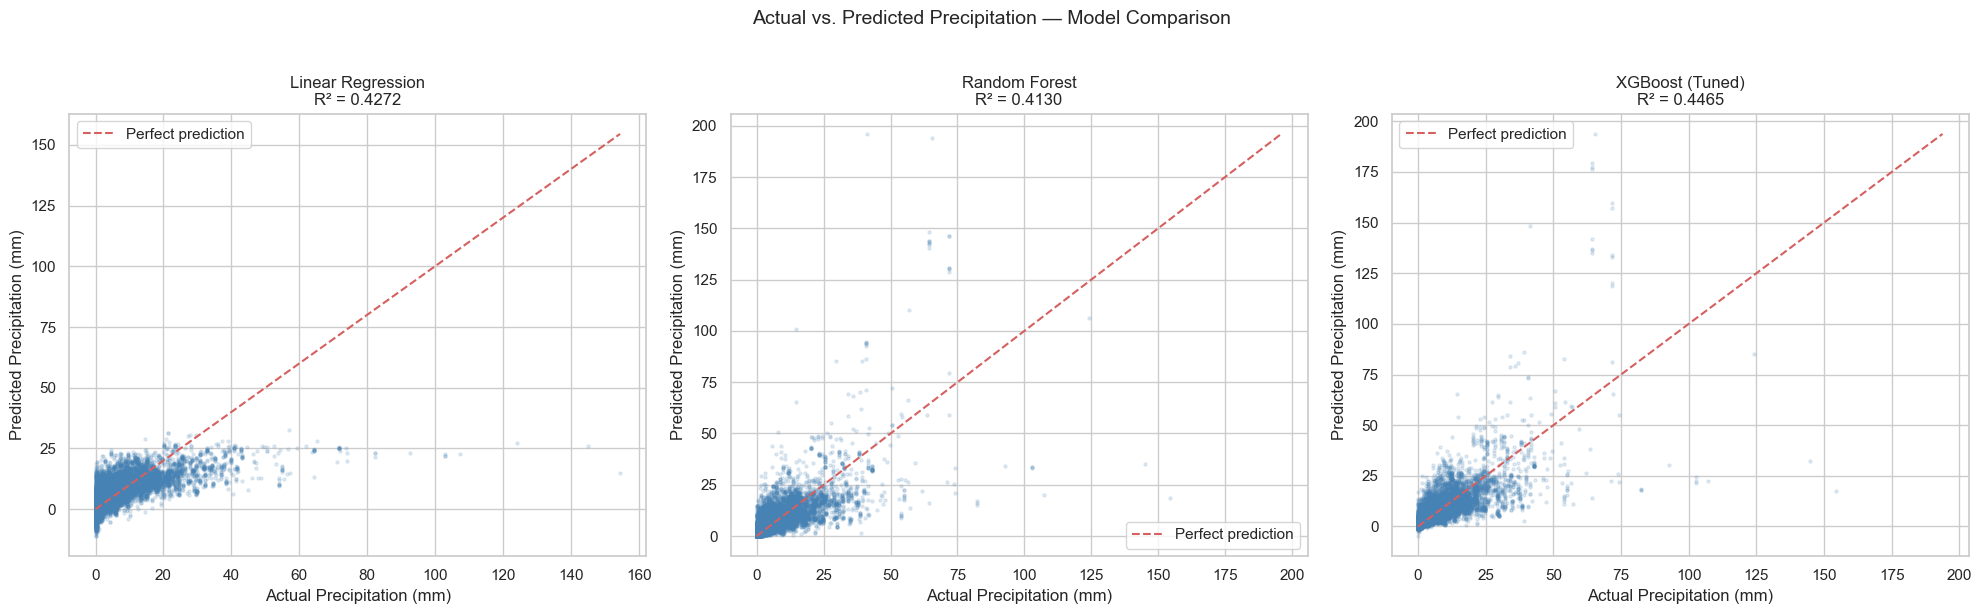

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models_data = [
    ('Linear Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('XGBoost (Tuned)', xgb_pred)
]

for ax, (name, pred) in zip(axes, models_data):
    ax.scatter(y_test, pred, alpha=0.15, s=5, color='steelblue')
    lims = [0, max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, pred):.4f}')
    ax.set_xlabel('Actual Precipitation (mm)')
    ax.set_ylabel('Predicted Precipitation (mm)')
    ax.legend()

plt.suptitle('Actual vs. Predicted Precipitation — Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

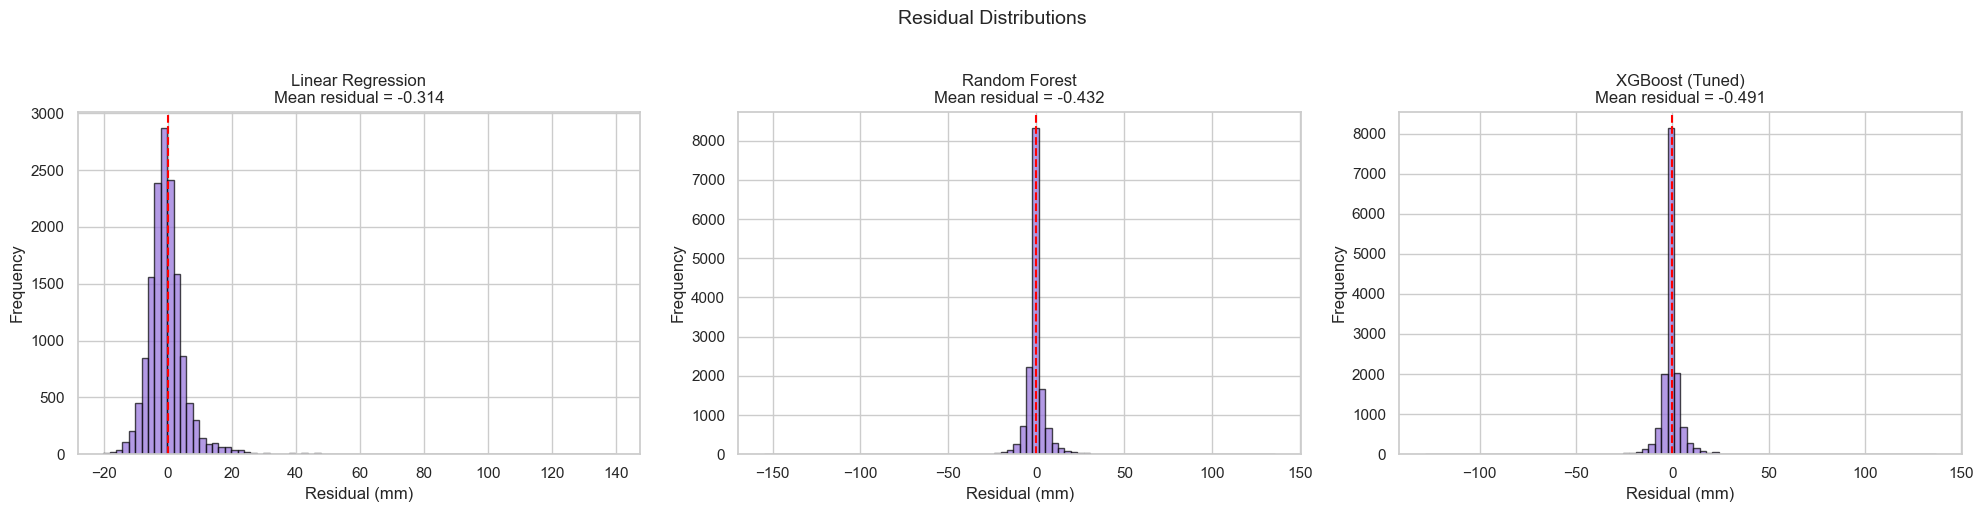

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (name, pred) in zip(axes, models_data):
    residuals = y_test.values - pred
    ax.hist(residuals, bins=80, edgecolor='black', alpha=0.7, color='mediumpurple')
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(f'{name}\nMean residual = {residuals.mean():.3f}')
    ax.set_xlabel('Residual (mm)')
    ax.set_ylabel('Frequency')

plt.suptitle('Residual Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

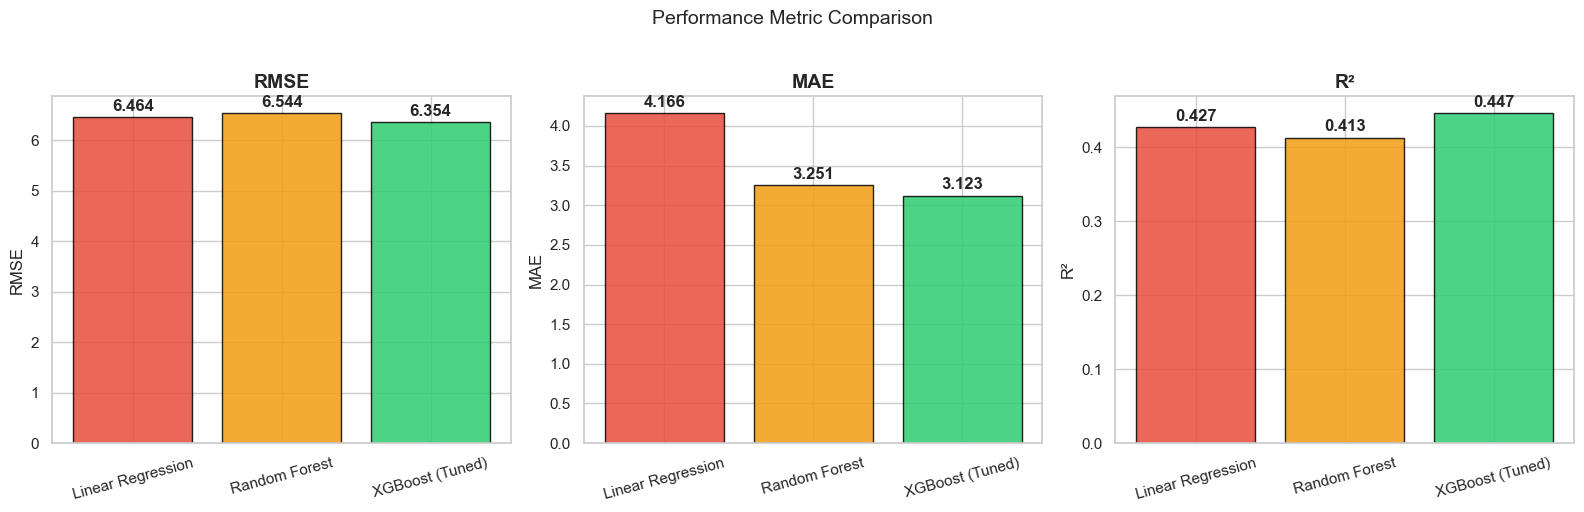

In [16]:
metric_names = ['RMSE', 'MAE', 'R²']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metric_names):
    values = results_df[metric].values
    colors = ['#e74c3c', '#f39c12', '#2ecc71']
    bars = ax.bar(results_df.index, values, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(values),
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Performance Metric Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

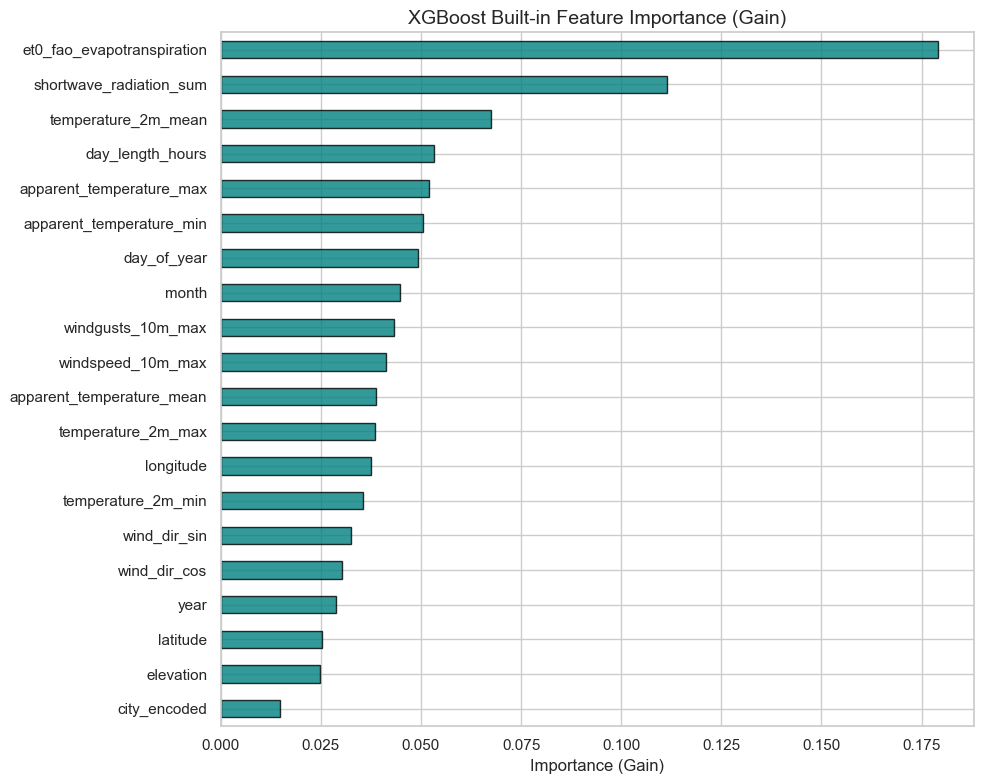

In [17]:
importance = xgb_model.feature_importances_
feat_imp = pd.Series(importance, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.plot(kind='barh', ax=ax, color='teal', edgecolor='black', alpha=0.8)
ax.set_title('XGBoost Built-in Feature Importance (Gain)', fontsize=14)
ax.set_xlabel('Importance (Gain)')
plt.tight_layout()
plt.show()

In [18]:
import shap

explainer = shap.TreeExplainer(xgb_model)

X_test_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print(f"SHAP values computed for {X_test_sample.shape[0]} test samples.")

SHAP values computed for 2000 test samples.


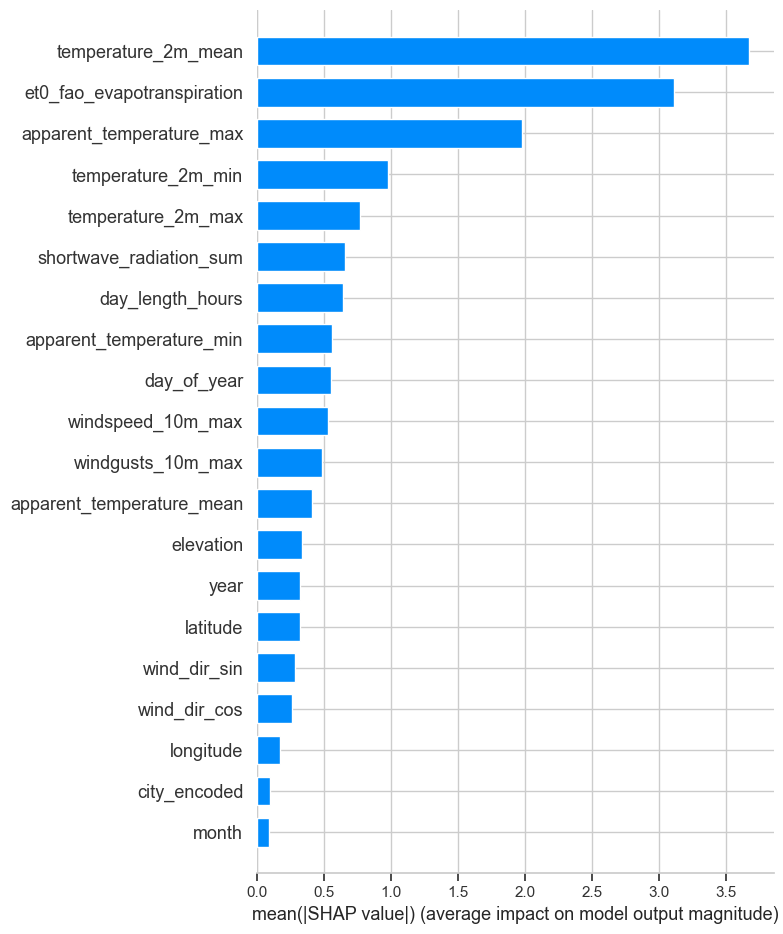

In [19]:
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', show=True)

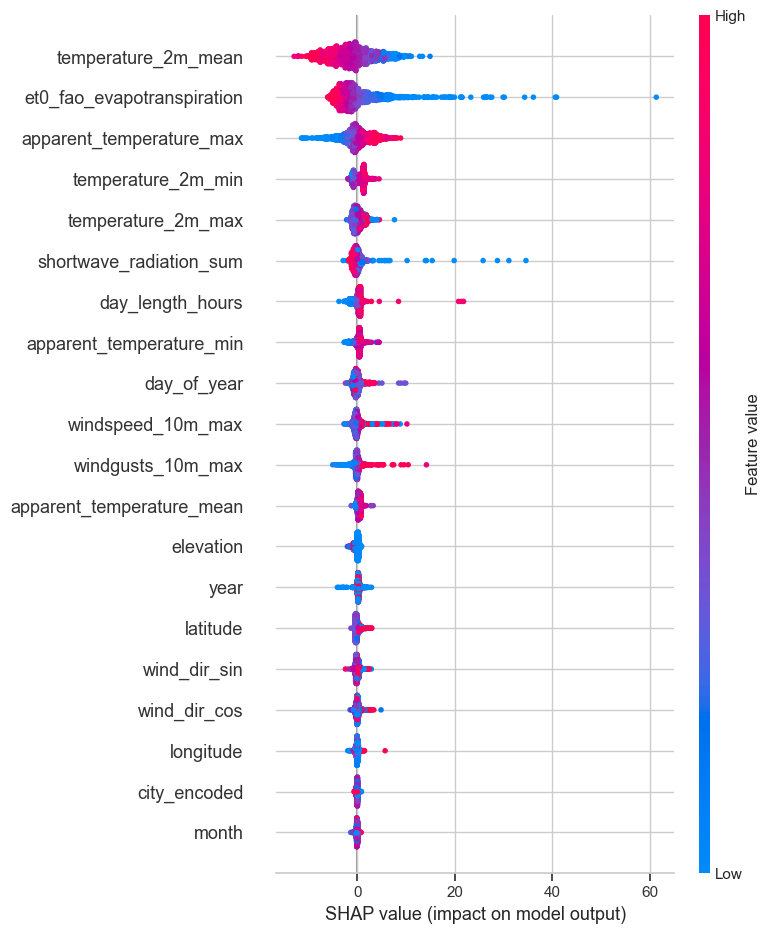

In [20]:
shap.summary_plot(shap_values, X_test_sample, show=True)

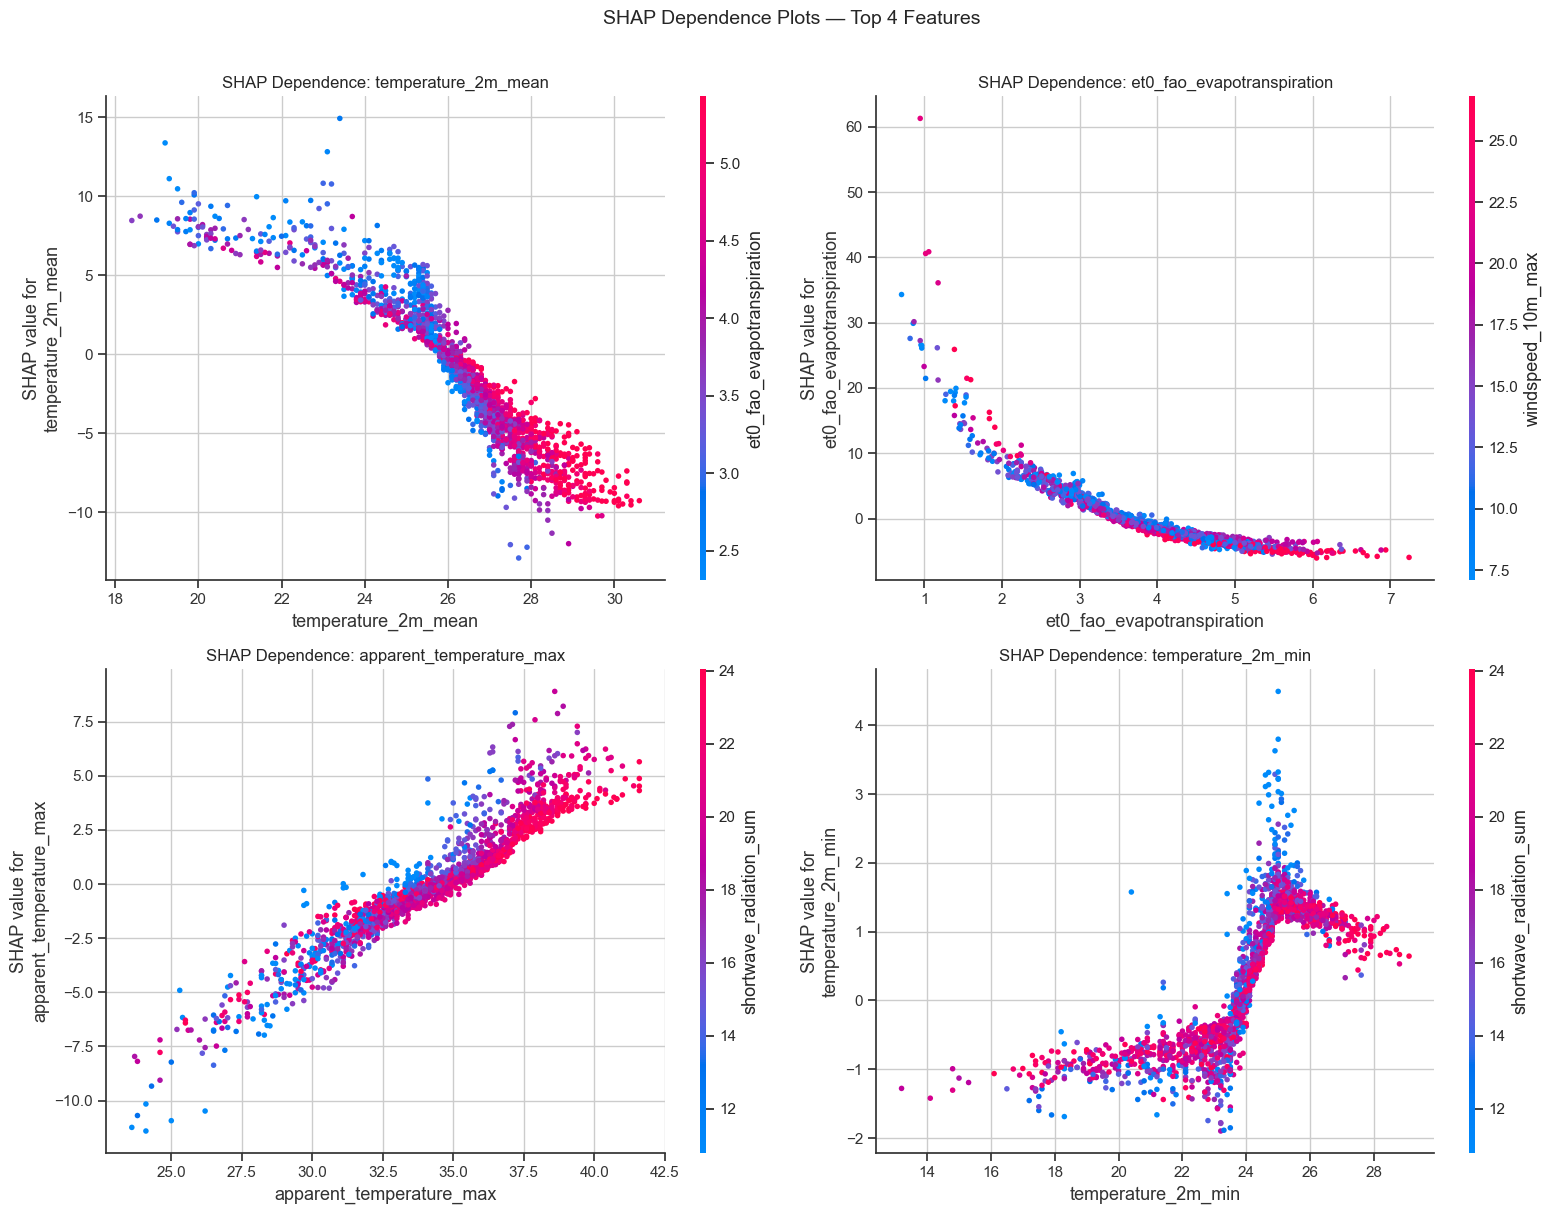

In [21]:
top_features = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).sort_values(ascending=False)
top_4 = top_features.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, feat in zip(axes.flatten(), top_4):
    shap.dependence_plot(feat, shap_values, X_test_sample, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=12)

plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

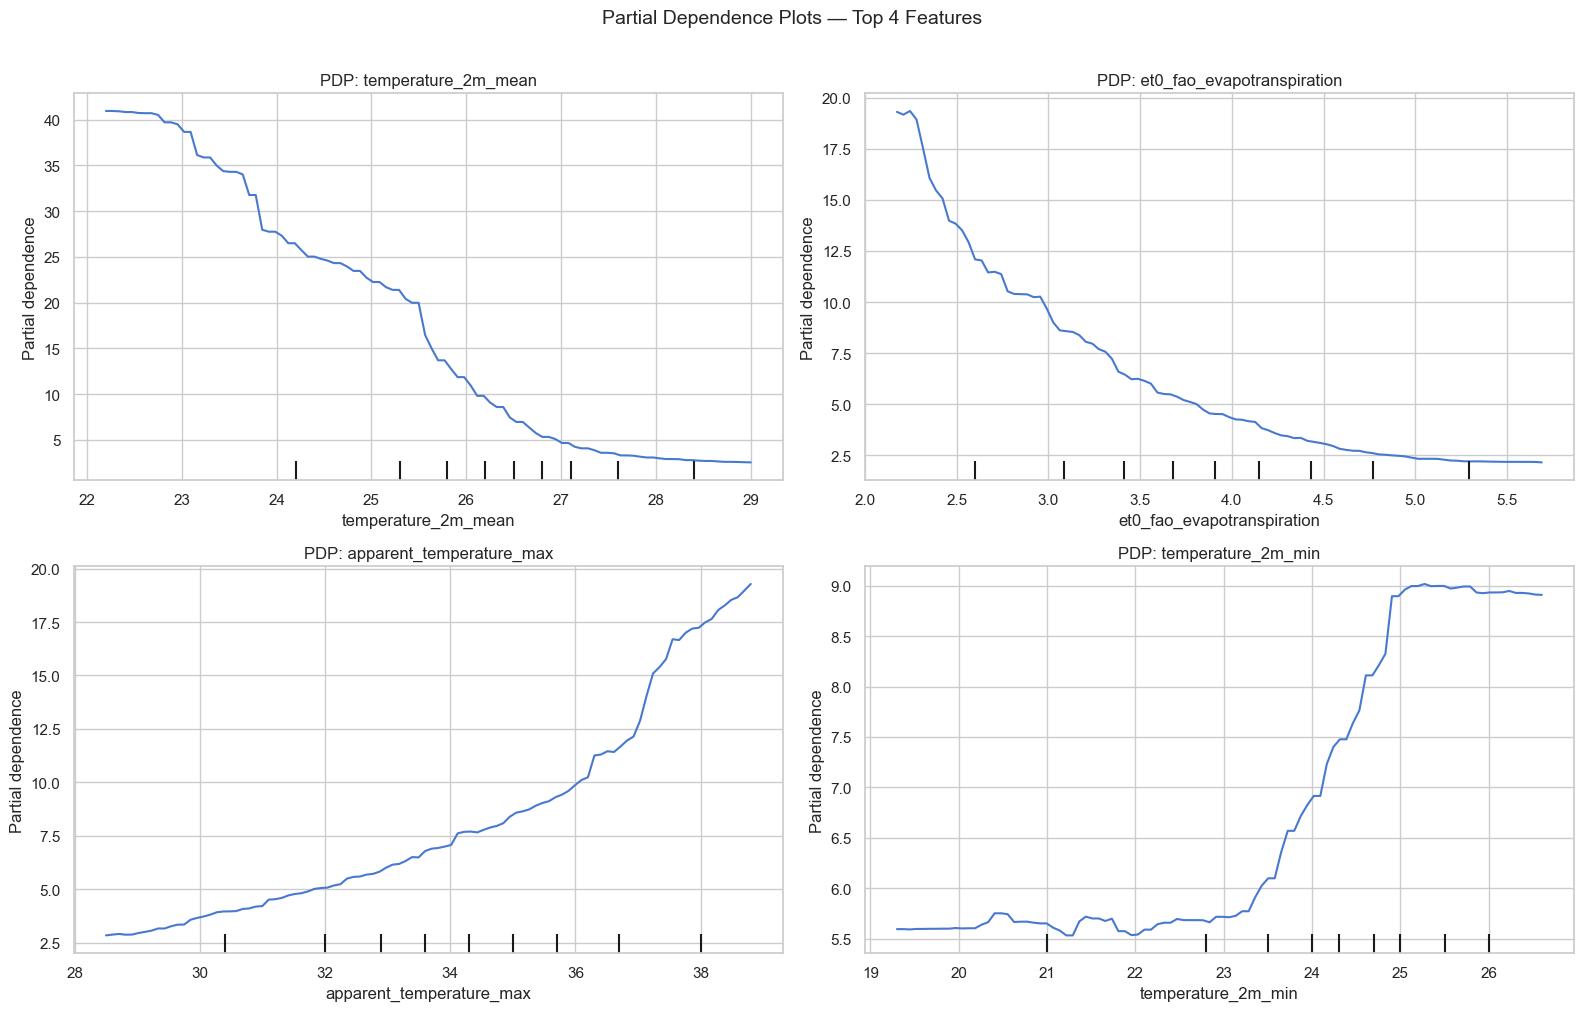

In [22]:
from sklearn.inspection import PartialDependenceDisplay

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

top_4_indices = [feature_cols.index(f) for f in top_4]

for ax, feat_idx, feat_name in zip(axes.flatten(), top_4_indices, top_4):
    PartialDependenceDisplay.from_estimator(
        xgb_model, X_train.sample(n=5000, random_state=42),
        features=[feat_idx], feature_names=feature_cols,
        ax=ax, kind='average'
    )
    ax.set_title(f'PDP: {feat_name}', fontsize=12)

plt.suptitle('Partial Dependence Plots — Top 4 Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Explaining prediction for a high-rainfall day:
  Actual precipitation: 71.9 mm
  Predicted: 65.4 mm


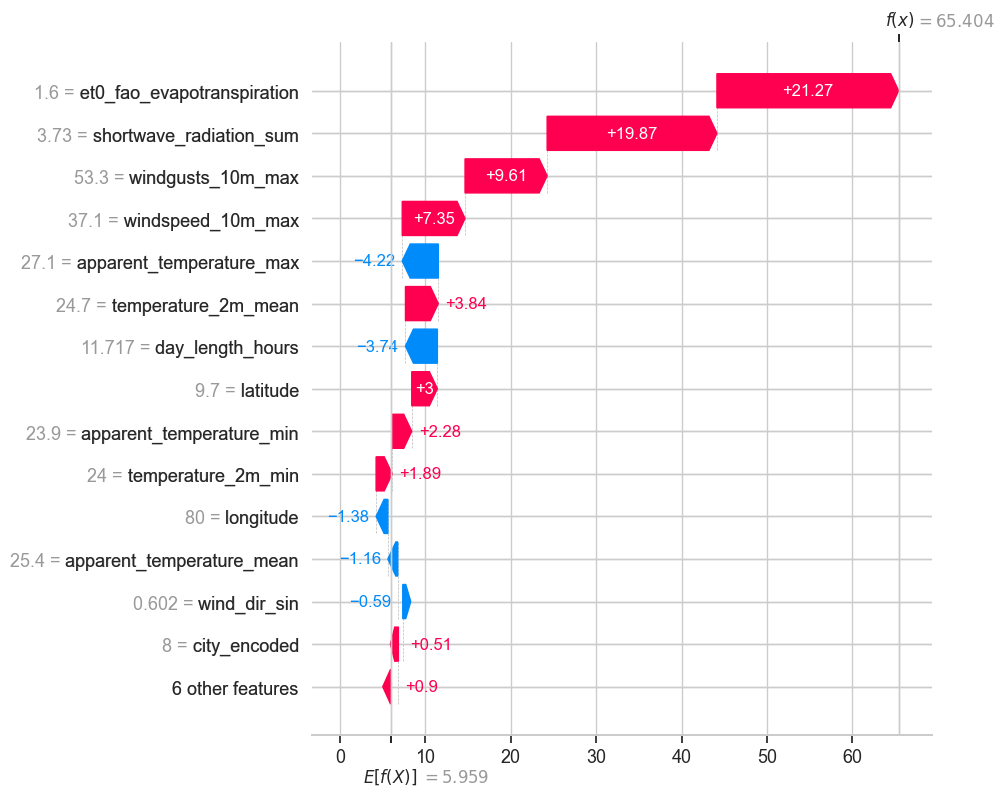

In [23]:
explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(shap_values.shape[0], explainer.expected_value),
    data=X_test_sample.values,
    feature_names=feature_cols
)

high_rain_idx = X_test_sample.index[y_test.loc[X_test_sample.index].argmax()]
sample_pos = list(X_test_sample.index).index(high_rain_idx)

print(f"Explaining prediction for a high-rainfall day:")
print(f"  Actual precipitation: {y_test.loc[high_rain_idx]:.1f} mm")
print(f"  Predicted: {xgb_model.predict(X_test_sample.iloc[[sample_pos]])[0]:.1f} mm")

shap.waterfall_plot(explanation[sample_pos], max_display=15, show=True)

In [24]:
import joblib

artifacts = {
    'model': xgb_model,
    'feature_cols': feature_cols,
    'label_encoder_city': le_city,
    'city_names': sorted(df['city'].unique().tolist()),
}

joblib.dump(artifacts, 'model_artifacts.joblib')
print("Model artifacts saved to 'model_artifacts.joblib'")
print(f"Features expected by model: {feature_cols}")

Model artifacts saved to 'model_artifacts.joblib'
Features expected by model: ['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'apparent_temperature_max', 'apparent_temperature_min', 'apparent_temperature_mean', 'shortwave_radiation_sum', 'windspeed_10m_max', 'windgusts_10m_max', 'et0_fao_evapotranspiration', 'latitude', 'longitude', 'elevation', 'month', 'day_of_year', 'year', 'day_length_hours', 'wind_dir_sin', 'wind_dir_cos', 'city_encoded']
